In [6]:
import os
os.listdir()

['.config', 'economic_data_feature_engineered (3).csv', 'sample_data']

Training shape: (138, 68)
Testing shape: (35, 68)
ARIMA Forecast Completed
countryid                        int64
country_name                    object
webname                         object
region                          object
world_rank                       int64
                                ...   
inflation_(%)_lag1             float64
fdi_inflow_(millions)_lag1     float64
public_debt_(%_of_gdp)_lag1    float64
Year_lag1                      float64
Month_lag1                     float64
Length: 67, dtype: object
countryid                        int64
country_name                    object
webname                         object
region                          object
world_rank                       int64
                                ...   
inflation_(%)_lag1             float64
fdi_inflow_(millions)_lag1     float64
public_debt_(%_of_gdp)_lag1    float64
Year_lag1                      float64
Month_lag1                     float64
Length: 67, dtype: object


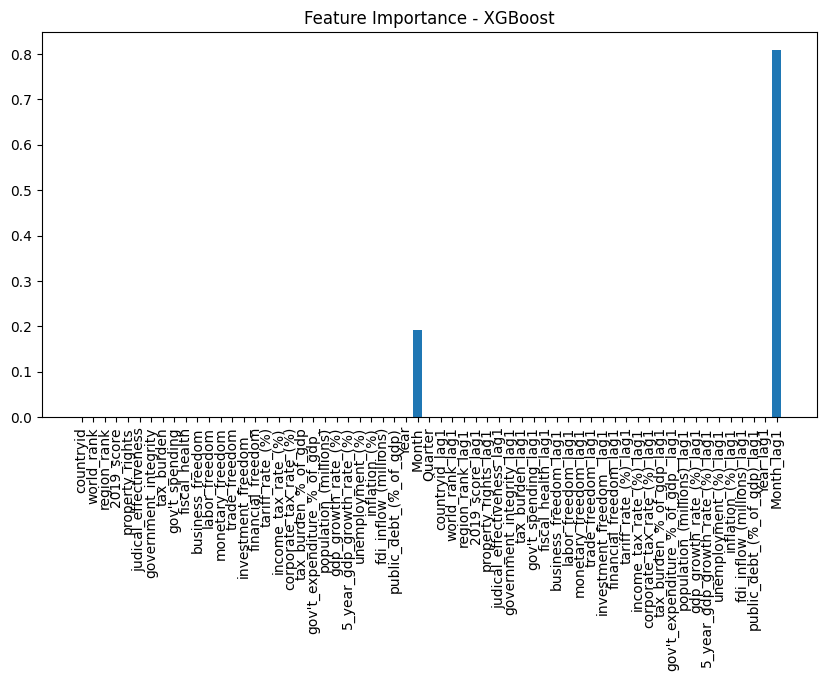

XGBoost Training Completed
ARIMA Results
MAE: 1.0285714285714285
RMSE: 1.2421180068162376
Bias: -0.5142857142857142


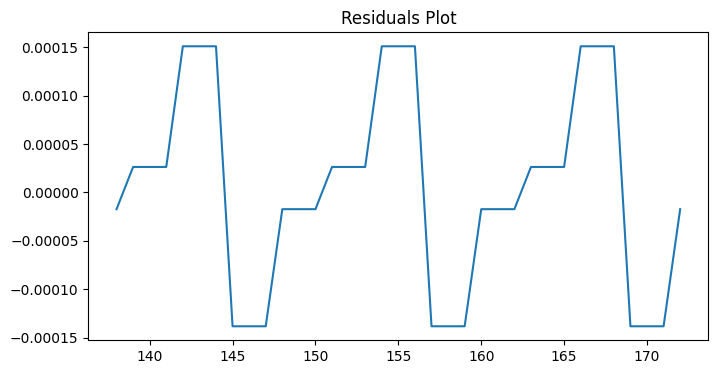


XGBoost Results
MAE: 8.511883871895927e-05
RMSE: 0.00010501678455958619
Bias: -5.984306335449219e-06


,Model,MAE,RMSE,Bias
0,ARIMA,1.028571,1.242118,-0.514286
1,XGBoost,0.000085,0.000105,-0.000006


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
df = pd.read_csv("economic_data_feature_engineered (3).csv")
df.head()
df.columns
# Train-Test Split
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

# Assume last column is target
target = df.columns[-1]

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA
model_arima = ARIMA(y_train, order=(1,1,1))
model_arima_fit = model_arima.fit()

# Forecast
forecast_arima = model_arima_fit.forecast(steps=len(y_test))

print("ARIMA Forecast Completed")
# Remove Date column if exists
if 'Date' in X_train.columns:
    X_train = X_train.drop(columns=['Date'])
    X_test = X_test.drop(columns=['Date'])

print(X_train.dtypes)
print(X_train.dtypes)
# Keep only numeric columns
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model_xgb.fit(X_train, y_train)
import matplotlib.pyplot as plt

importances = model_xgb.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,5))
plt.bar(features, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance - XGBoost")
plt.show()
forecast_xgb = model_xgb.predict(X_test)

print("XGBoost Training Completed")
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(y_test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test, forecast_arima))
bias_arima = np.mean(forecast_arima - y_test)

print("ARIMA Results")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("Bias:", bias_arima)
mae_xgb = mean_absolute_error(y_test, forecast_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, forecast_xgb))
bias_xgb = np.mean(forecast_xgb - y_test)
residuals = y_test - forecast_xgb

plt.figure(figsize=(8,4))
plt.plot(residuals)
plt.title("Residuals Plot")
plt.show()

print("\nXGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("Bias:", bias_xgb)
results = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost"],
    "MAE": [mae_arima, mae_xgb],
    "RMSE": [rmse_arima, rmse_xgb],
    "Bias": [bias_arima, bias_xgb]
})

results

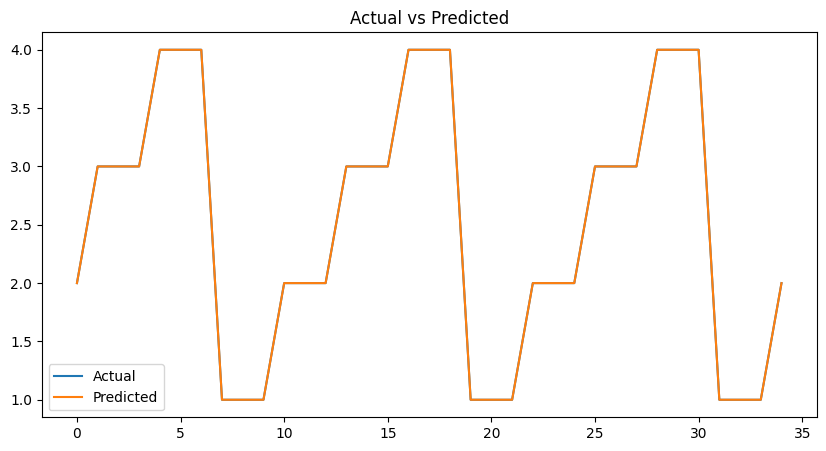

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(forecast_xgb, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05]
}

grid = GridSearchCV(XGBRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Use best model
best_model = grid.best_estimator_
forecast_xgb = best_model.predict(X_test)

In [42]:
results.to_csv("model_comparison_results.csv", index=False)

In [44]:
rolling_predictions = []
rolling_actuals = []

for i in range(len(y_test)):
    train_dynamic = df[:train_size + i]
    test_dynamic = df[train_size + i: train_size + i + 1]

    X_train_dyn = train_dynamic.drop(columns=[target]).select_dtypes(include=[np.number])
    y_train_dyn = train_dynamic[target]

    X_test_dyn = test_dynamic.drop(columns=[target]).select_dtypes(include=[np.number])
    y_test_dyn = test_dynamic[target]

    model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
    model.fit(X_train_dyn, y_train_dyn)

    pred = model.predict(X_test_dyn)

    rolling_predictions.append(pred[0])
    rolling_actuals.append(y_test_dyn.values[0])

print("Backtesting Completed")
mae_backtest = mean_absolute_error(rolling_actuals, rolling_predictions)
rmse_backtest = np.sqrt(mean_squared_error(rolling_actuals, rolling_predictions))

print("Backtesting MAE:", mae_backtest)
print("Backtesting RMSE:", rmse_backtest)

Backtesting Completed
Backtesting MAE: 8.096013750348772e-05
Backtesting RMSE: 9.988483294175204e-05


In [23]:
!pip install xgboost